In [1]:
import os          
import zipfile   
import shutil   
import numpy as np        
import pandas as pd       

import matplotlib.pyplot as plt
from PIL import Image   
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns    

In [2]:
zip_path    = "archive.zip"         
extract_dir = "dataset_extracted"   

if not os.path.exists(extract_dir):
    print("Extracting zip file... (this may take a moment)")
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_dir)
    print("Extraction complete!")
else:
    print("Already extracted and skipping.")

for root, dirs, files in os.walk(extract_dir):
    level = root.replace(extract_dir, '').count(os.sep)
    indent = '  ' * level
    print(f"{indent}{os.path.basename(root)}/")
    if level < 2:   
        print(f"{indent}   ({len(files)} files)")

Already extracted and skipping.
dataset_extracted/
   (1 files)
  train/
     (0 files)
    train/


In [3]:
csv_path = os.path.join(extract_dir, "train_labels.csv")
labels_df = pd.read_csv(csv_path)

print("First 5 rows of the labels file:")
print(labels_df.head())
print()
print("Class distribution:")
print(labels_df['label'].value_counts())

First 5 rows of the labels file:
      filename         label
0  Image_1.jpg  without_mask
1  Image_2.jpg  without_mask
2  Image_3.jpg  without_mask
3  Image_4.jpg  without_mask
4  Image_5.jpg  without_mask

Class distribution:
label
without_mask    5632
with_mask       5632
Name: count, dtype: int64


In [4]:
raw_images_dir  = os.path.join(extract_dir, "train", "train")
organised_dir   = "dataset"   

if not os.path.exists(organised_dir):
    print("Organising images into class folders...")

    # Create the two class sub-folders
    os.makedirs(os.path.join(organised_dir, "with_mask"),    exist_ok=True)
    os.makedirs(os.path.join(organised_dir, "without_mask"), exist_ok=True)

    # Copy each image to the correct sub-folder based on its label
    for _, row in labels_df.iterrows():
        filename = row['filename']   # e.g. 'Image_1.jpg'
        label    = row['label']      # e.g. 'with_mask'

        src  = os.path.join(raw_images_dir, filename)
        dest = os.path.join(organised_dir, label, filename)

        if os.path.exists(src):
            shutil.copy(src, dest)

    print("Done! Folder structure ready.")
else:
    print("Already organised — skipping.")

# Verify counts
for cls in ['with_mask', 'without_mask']:
    count = len(os.listdir(os.path.join(organised_dir, cls)))
    print(f"  {cls}: {count} images")

Already organised — skipping.
  with_mask: 5632 images
  without_mask: 5632 images


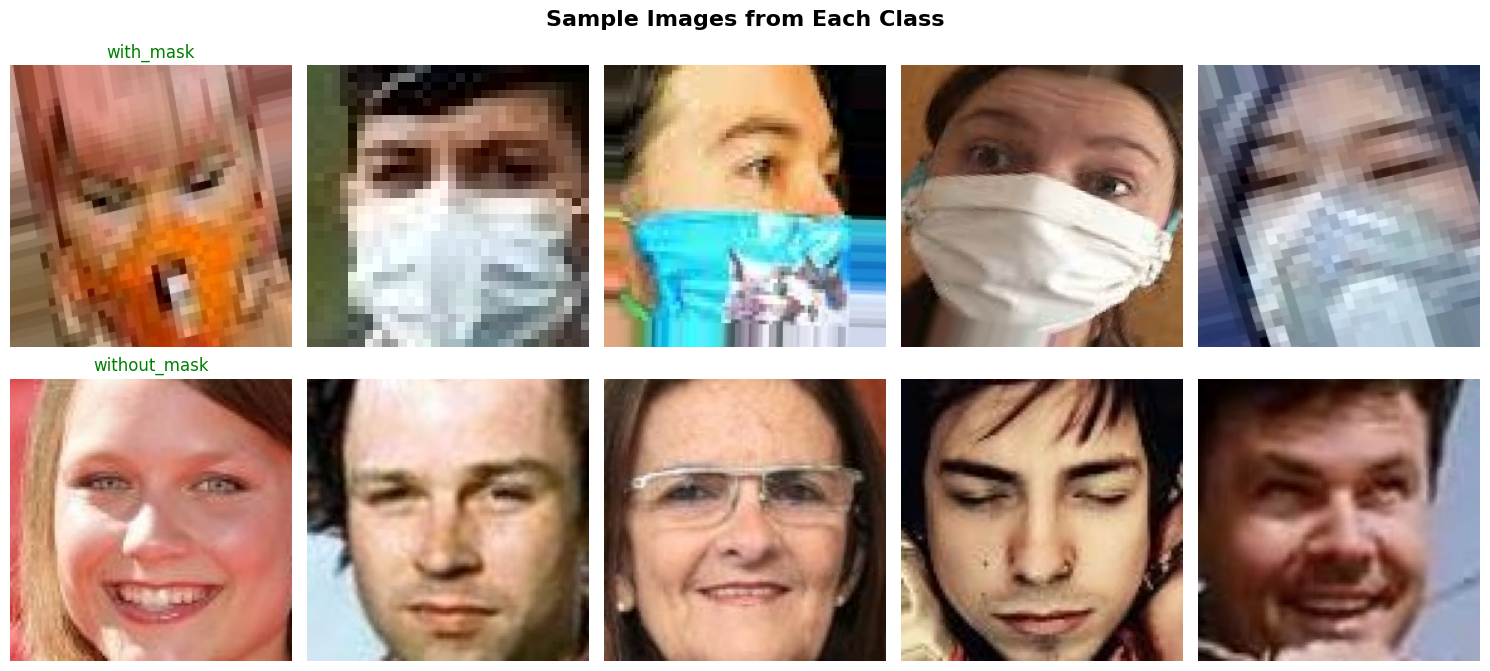

In [5]:
fig, axes = plt.subplots(2, 5, figsize=(15, 7))
fig.suptitle("Sample Images from Each Class", fontsize=16, fontweight='bold')

for row_idx, cls in enumerate(['with_mask', 'without_mask']):
    cls_dir  = os.path.join(organised_dir, cls)
    # Pick the first 5 images in that class folder
    samples  = os.listdir(cls_dir)[:5]

    for col_idx, fname in enumerate(samples):
        img_path = os.path.join(cls_dir, fname)
        img      = Image.open(img_path)

        axes[row_idx, col_idx].imshow(img)
        axes[row_idx, col_idx].axis('off')
        # Label the first column of each row with the class name
        if col_idx == 0:
            axes[row_idx, col_idx].set_title(cls, fontsize=12, color='green' if 'with' in cls else 'red')

plt.tight_layout()
plt.show()

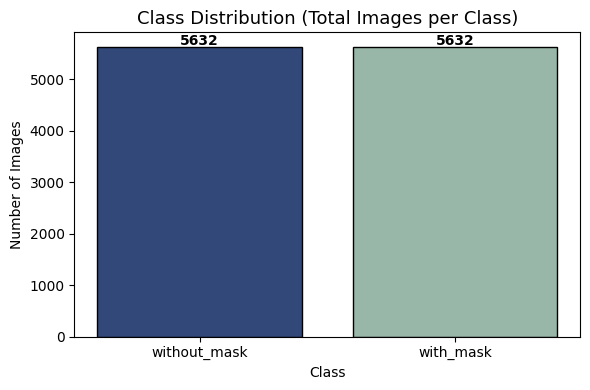

In [6]:
# Showing class distribution on a bar chart 

class_counts = labels_df['label'].value_counts()

plt.figure(figsize=(6, 4))
plt.bar(class_counts.index, class_counts.values,
        color=['#324879', '#99b7a9'], edgecolor='black')
plt.title("Class Distribution (Total Images per Class)", fontsize=13)
plt.ylabel("Number of Images")
plt.xlabel("Class")
for i, v in enumerate(class_counts.values):
    plt.text(i, v + 30, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

# Round 1 Testing 

In [7]:
IMG_HEIGHT = 128     
IMG_WIDTH  = 128
BATCH_SIZE = 32    

In [8]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    organised_dir,
    validation_split = 0.2,
    subset           = "training",
    image_size       = (IMG_HEIGHT, IMG_WIDTH),
    seed             = 123,
    batch_size       = BATCH_SIZE
)


Found 11264 files belonging to 2 classes.
Using 9012 files for training.


In [9]:
val_ds = tf.keras.utils.image_dataset_from_directory(
    organised_dir,
    validation_split = 0.2,
    subset           = "validation",
    seed             = 123,
    image_size       = (IMG_HEIGHT, IMG_WIDTH),
    batch_size       = BATCH_SIZE
)

Found 11264 files belonging to 2 classes.
Using 2252 files for validation.


In [10]:
class_names = train_ds.class_names
print("Class names:", class_names)

Class names: ['with_mask', 'without_mask']


In [11]:
for image_batch, label_batch in train_ds.take(1):   
    print("Image batch shape:", image_batch.shape)
    print("Label batch shape:", label_batch.shape)
    print("Sample labels (0=with_mask, 1=without_mask):", label_batch[:8].numpy())


Image batch shape: (32, 128, 128, 3)
Label batch shape: (32,)
Sample labels (0=with_mask, 1=without_mask): [0 0 0 1 0 0 1 1]


In [12]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds   = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

# Building Model without augmentation

In [13]:
 
model1 = Sequential([
    layers.Rescaling(1./255, input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)),

    layers.Conv2D(16, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(32, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(64, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),

    layers.Flatten(),

    layers.Dense(128, activation='relu'),

    layers.Dense(1, activation='sigmoid')
])

model1.summary()

c:\Users\USER\anaconda3\envs\tf\lib\site-packages\keras\src\layers\preprocessing\data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 128, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     2,097,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,120,993 (8.09 MB)

 Trainable params: 2,120,993 (8.09 MB)

 Non-trainable params: 0 (0.00 B)

In [14]:
model1.compile(
    optimizer = 'adam',
    loss      = 'binary_crossentropy',
    metrics   = ['accuracy']
)

In [15]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor              = 'val_loss',
    patience             = 5,
    restore_best_weights = True,
    verbose              = 1
)

EPOCHS_1 = 20    

history1 = model1.fit(
    train_ds,
    validation_data = val_ds,
    epochs          = EPOCHS_1,
    callbacks       = [early_stop]
)

Epoch 1/20
282/282 ━━━━━━━━━━━━━━━━━━━━ 34s 100ms/step - accuracy: 0.9127 - loss: 0.2051 - val_accuracy: 0.9609 - val_loss: 0.1048
Epoch 2/20
282/282 ━━━━━━━━━━━━━━━━━━━━ 26s 93ms/step - accuracy: 0.9710 - loss: 0.0758 - val_accuracy: 0.9716 - val_loss: 0.0703
Epoch 3/20
282/282 ━━━━━━━━━━━━━━━━━━━━ 26s 93ms/step - accuracy: 0.9798 - loss: 0.0555 - val_accuracy: 0.9707 - val_loss: 0.0857
Epoch 4/20
282/282 ━━━━━━━━━━━━━━━━━━━━ 27s 95ms/step - accuracy: 0.9846 - loss: 0.0427 - val_accuracy: 0.9734 - val_loss: 0.0722
Epoch 5/20
282/282 ━━━━━━━━━━━━━━━━━━━━ 27s 96ms/step - accuracy: 0.9851 - loss: 0.0377 - val_accuracy: 0.9645 - val_loss: 0.1013
Epoch 6/20
282/282 ━━━━━━━━━━━━━━━━━━━━ 31s 110ms/step - accuracy: 0.9854 - loss: 0.0371 - val_accuracy: 0.9769 - val_loss: 0.0703
Epoch 7/20
282/282 ━━━━━━━━━━━━━━━━━━━━ 29s 104ms/step - accuracy: 0.9922 - loss: 0.0225 - val_accuracy: 0.9738 - val_loss: 0.0814
Epoch 8/20
282/282 ━━━━━━━━━━━━━━━━━━━━ 30s 107ms/step - accuracy: 0.9952 - loss: 0.014

#

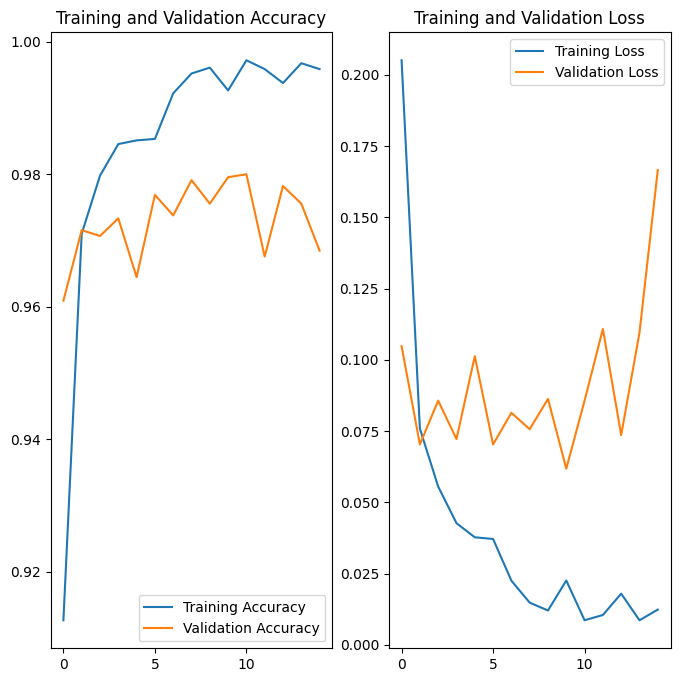

In [19]:
acc = history1.history['accuracy']
val_acc = history1.history['val_accuracy']

loss = history1.history['loss']
val_loss = history1.history['val_loss']

epochs_range = range(len(acc))

plt.figure(figsize=(8, 8))

# Accuracy
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

# Loss
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')

plt.show()

# Prediction with model 1

In [20]:
import requests
from PIL import Image
from io import BytesIO

def predict_new_image(model, image_source, class_names, img_size=(128, 128)):

    # Load image from URL or local file
    if image_source.startswith("http"):
        # Download image from internet
        response = requests.get(image_source)
        img = Image.open(BytesIO(response.content)).convert("RGB")
    else:
        # Load from local file path
        img = Image.open(image_source).convert("RGB")

    # Preprocess
    img = img.resize(img_size)                        # resize to 128x128
    img_array = tf.keras.utils.img_to_array(img)      # convert to array
    img_array = tf.expand_dims(img_array, 0)          # add batch dimension

    # Predict 
    # training=False → augmentation layers are OFF (important for model2)
    pred = model(img_array, training=False)
    score = float(pred[0][0])

    # Result
    if score > 0.5:
        label      = class_names[1]   # without_mask
        confidence = score
    else:
        label      = class_names[0]   # with_mask
        confidence = 1 - score

    # Show image + result
    plt.figure(figsize=(4, 4))
    plt.imshow(img)
    plt.axis('off')
    color = 'red' if label == 'without_mask' else 'green'
    plt.title(f"Prediction : {label}\nConfidence : {confidence*100:.1f}%",
              color=color, fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

    print(f"Prediction : {label}")
    print(f"Confidence : {confidence*100:.1f}%")

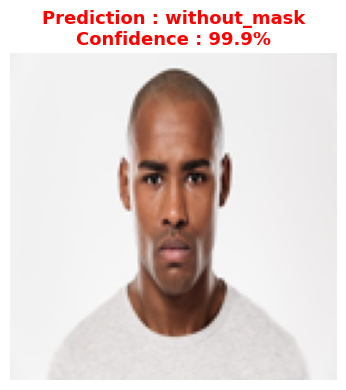

Prediction : without_mask
Confidence : 99.9%


In [21]:
predict_new_image(
    model       = model1,
    image_source= "https://img.magnific.com/free-photo/serious-young-african-man-standing-isolated_171337-9633.jpg?semt=ais_hybrid&w=740&q=80",
    class_names = class_names
)

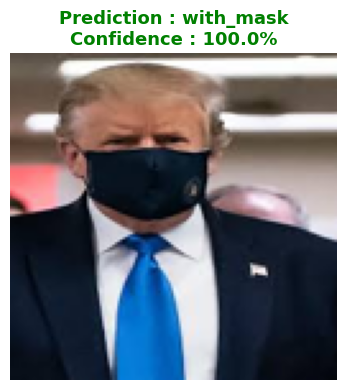

Prediction : with_mask
Confidence : 100.0%


In [22]:
predict_new_image(
    model       = model1,
    image_source= "https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcQkRchzYm5uH4_THgNsUn8LBwXyQNftOo2UqQ&s",
    class_names = class_names
)


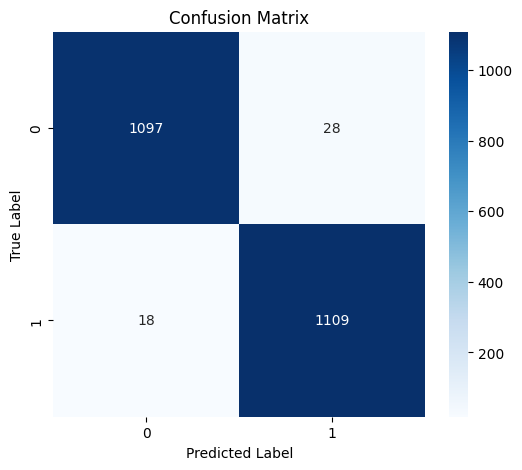

Classification Report:

              precision    recall  f1-score   support

           0       0.98      0.98      0.98      1125
           1       0.98      0.98      0.98      1127

    accuracy                           0.98      2252
   macro avg       0.98      0.98      0.98      2252
weighted avg       0.98      0.98      0.98      2252



In [23]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report

y_true = []
y_pred = []

# Collect predictions and true labels
for images, labels in val_ds:   
    preds = model1.predict(images, verbose=0)
    
    y_true.extend(labels.numpy())
    
    y_pred.extend((preds > 0.5).astype(int).flatten())

# Convert to numpy arrays
y_true = np.array(y_true)
y_pred = np.array(y_pred)

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

# Ploting Confusion Matrix
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

# Classification Report
print("Classification Report:\n")
print(classification_report(y_true, y_pred))

# Model 2 with data augmentation and dropout

In [24]:
data_augmentation = keras.Sequential([

    layers.RandomFlip("horizontal", input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)),

    layers.RandomRotation(0.1),

    layers.RandomZoom(0.1),], name="data_augmentation")

c:\Users\USER\anaconda3\envs\tf\lib\site-packages\keras\src\layers\preprocessing\data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


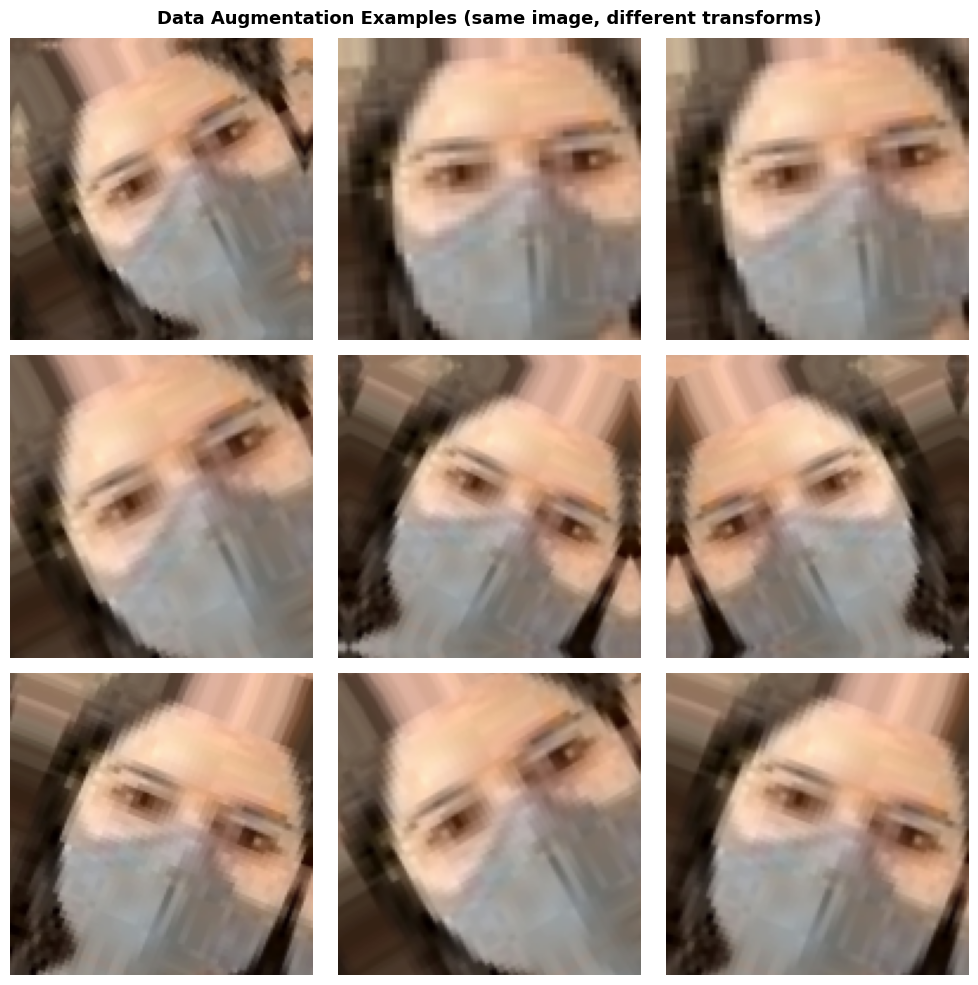

In [25]:
plt.figure(figsize=(10, 10))
plt.suptitle("Data Augmentation Examples (same image, different transforms)",
             fontsize=13, fontweight='bold')

for images, _ in train_ds.take(1):   # grab one batch
    one_image = tf.expand_dims(images[0], 0)   # pick just the first image
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        augmented = data_augmentation(one_image, training=True)   # training=True applies random transforms
        plt.imshow(augmented[0].numpy().astype("uint8"))
        plt.axis("off")

plt.tight_layout()
plt.show()

In [26]:
model2 = Sequential([

    data_augmentation,

    layers.Rescaling(1./255),

    layers.Conv2D(32, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),   # 128 → 64

    layers.Conv2D(64, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),   # 64 → 32

    layers.Conv2D(128, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),   # 32 → 16

    layers.Dropout(0.2),

    layers.Flatten(),

    layers.Dense(128, activation='relu'),

    layers.Dropout(0.2),

    layers.Dense(1, activation='sigmoid')
])

model2.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_1 (Rescaling)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     4,194,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,287,809 (16.36 MB)

 Trainable params: 4,287,809 (16.36 MB)

 Non-trainable params: 0 (0.00 B)

In [27]:
model2.compile(
    optimizer = tf.keras.optimizers.Adam(learning_rate=0.001),
    loss      = 'binary_crossentropy',
    metrics   = ['accuracy']
)

In [28]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor              = 'val_loss',
    patience             = 5,
    restore_best_weights = True,
    verbose              = 1
)

EPOCHS_2 = 20    

history2 = model2.fit(
    train_ds,
    validation_data = val_ds,
    epochs          = EPOCHS_2,
    callbacks       = [early_stop]
)

Epoch 1/20
282/282 ━━━━━━━━━━━━━━━━━━━━ 81s 283ms/step - accuracy: 0.9149 - loss: 0.2186 - val_accuracy: 0.9445 - val_loss: 0.1802
Epoch 2/20
282/282 ━━━━━━━━━━━━━━━━━━━━ 85s 303ms/step - accuracy: 0.9484 - loss: 0.1468 - val_accuracy: 0.9512 - val_loss: 0.1330
Epoch 3/20
282/282 ━━━━━━━━━━━━━━━━━━━━ 91s 323ms/step - accuracy: 0.9572 - loss: 0.1230 - val_accuracy: 0.9472 - val_loss: 0.1797
Epoch 4/20
282/282 ━━━━━━━━━━━━━━━━━━━━ 89s 314ms/step - accuracy: 0.9646 - loss: 0.1033 - val_accuracy: 0.9623 - val_loss: 0.1230
Epoch 5/20
282/282 ━━━━━━━━━━━━━━━━━━━━ 90s 318ms/step - accuracy: 0.9672 - loss: 0.0903 - val_accuracy: 0.9685 - val_loss: 0.0744
Epoch 6/20
282/282 ━━━━━━━━━━━━━━━━━━━━ 163s 578ms/step - accuracy: 0.9694 - loss: 0.0808 - val_accuracy: 0.9574 - val_loss: 0.1140
Epoch 7/20
282/282 ━━━━━━━━━━━━━━━━━━━━ 111s 394ms/step - accuracy: 0.9714 - loss: 0.0802 - val_accuracy: 0.9689 - val_loss: 0.0828
Epoch 8/20
282/282 ━━━━━━━━━━━━━━━━━━━━ 111s 393ms/step - accuracy: 0.9694 - loss

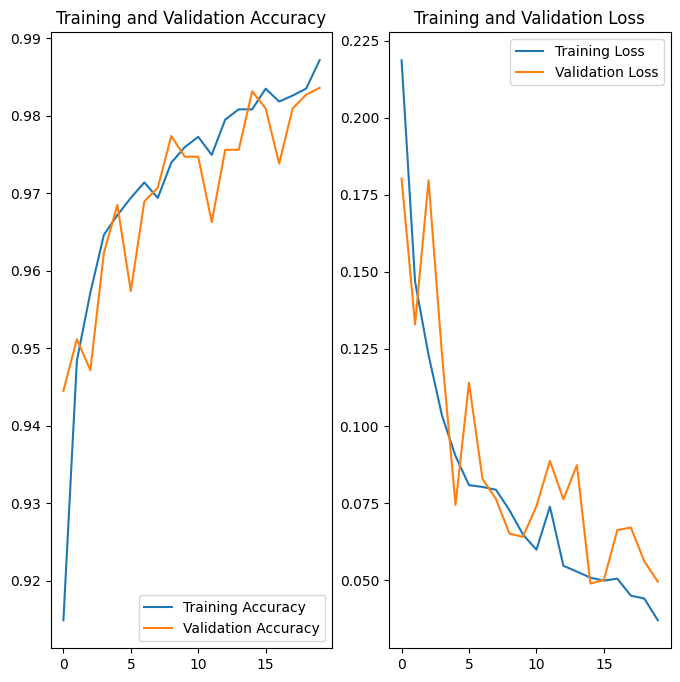

In [29]:
acc = history2.history['accuracy']
val_acc = history2.history['val_accuracy']

loss = history2.history['loss']
val_loss = history2.history['val_loss']

epochs_range = range(len(acc))

plt.figure(figsize=(8, 8))

# Accuracy
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

# Loss
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')

plt.show()

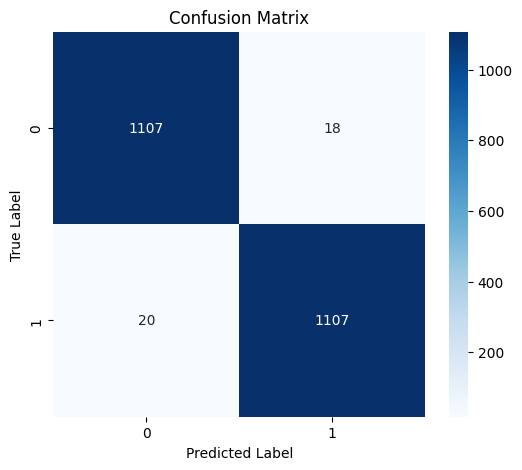

Classification Report:

              precision    recall  f1-score   support

           0       0.98      0.98      0.98      1125
           1       0.98      0.98      0.98      1127

    accuracy                           0.98      2252
   macro avg       0.98      0.98      0.98      2252
weighted avg       0.98      0.98      0.98      2252



In [30]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report

y_true = []
y_pred = []

# Collect predictions and true labels
for images, labels in val_ds:   
    preds = model2.predict(images, verbose=0)
    
    y_true.extend(labels.numpy())
    
    y_pred.extend((preds > 0.5).astype(int).flatten())

# Convert to numpy arrays
y_true = np.array(y_true)
y_pred = np.array(y_pred)

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

# Ploting Confusion Matrix
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

# Classification Report
print("Classification Report:\n")
print(classification_report(y_true, y_pred))

# Predicting with model 2

Testing on sample images from validation set:

True label: with_mask


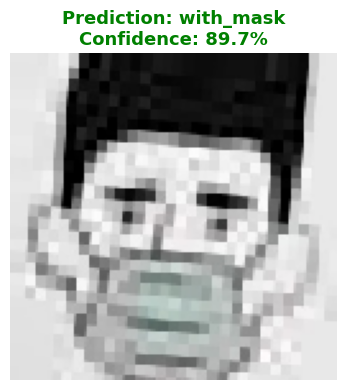

Predicted:  with_mask  (89.7% confidence) → CORRECT

True label: without_mask


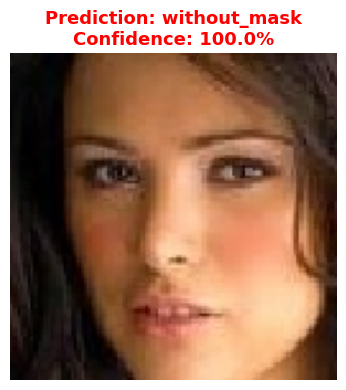

Predicted:  without_mask  (100.0% confidence) → CORRECT



In [31]:
# Predict function

def predict_image(model, img_path, class_names, img_size=(128, 128)):
    """
    Loads a single image, preprocesses it, runs the model,
    and shows the result with a confidence score.
    """
    # Load image and resize to match training size
    img = tf.keras.utils.load_img(img_path, target_size=img_size)

    # Convert to numpy array: shape (128, 128, 3)
    img_array = tf.keras.utils.img_to_array(img)

    # Add batch dimension: shape becomes (1, 128, 128, 3)
    # The model always expects a batch, even if it's just 1 image
    img_array = tf.expand_dims(img_array, 0)

    # Get raw prediction (sigmoid output in [0, 1])
    prediction = model.predict(img_array, verbose=0)
    score = prediction[0][0]  # single float value

    # score > 0.5  →  class 1 (without_mask)
    # score ≤ 0.5  →  class 0 (with_mask)
    predicted_class = class_names[1] if score > 0.5 else class_names[0]
    confidence      = score if score > 0.5 else 1 - score

    # Display image and result
    plt.figure(figsize=(4, 4))
    plt.imshow(img)
    plt.axis('off')
    color = 'red' if predicted_class == 'without_mask' else 'green'
    plt.title(f"Prediction: {predicted_class}\nConfidence: {confidence*100:.1f}%",
              color=color, fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

    return predicted_class, confidence


# Test with images from validation set 
# Grab a few images from each class and predict

print("Testing on sample images from validation set:\n")
for cls in class_names:
    cls_dir = os.path.join(organised_dir, cls)
    # Use the last few files (likely validation images since they're sorted)
    all_files = os.listdir(cls_dir)
    test_file = os.path.join(cls_dir, all_files[-1])  # last file

    print(f"True label: {cls}")
    predicted, conf = predict_image(model2, test_file, class_names)
    match = "CORRECT" if predicted == cls else " WRONG"
    print(f"Predicted:  {predicted}  ({conf*100:.1f}% confidence) → {match}\n")

In [32]:
import requests
from PIL import Image
from io import BytesIO

def predict_new_image(model, image_source, class_names, img_size=(128, 128)):

    # Load image from URL or local file
    if image_source.startswith("http"):
        # Download image from internet
        response = requests.get(image_source)
        img = Image.open(BytesIO(response.content)).convert("RGB")
    else:
        # Load from local file path
        img = Image.open(image_source).convert("RGB")

    #  Preprocess 
    img = img.resize(img_size)                        # resize to 128x128
    img_array = tf.keras.utils.img_to_array(img)      # convert to array
    img_array = tf.expand_dims(img_array, 0)          # add batch dimension

    # Predict
    # training=False → augmentation layers are OFF (important for model2)
    pred = model(img_array, training=False)
    score = float(pred[0][0])

    # Result
    if score > 0.5:
        label      = class_names[1]   # without_mask
        confidence = score
    else:
        label      = class_names[0]   # with_mask
        confidence = 1 - score

    # Show image + result
    plt.figure(figsize=(4, 4))
    plt.imshow(img)
    plt.axis('off')
    color = 'red' if label == 'without_mask' else 'green'
    plt.title(f"Prediction : {label}\nConfidence : {confidence*100:.1f}%",
              color=color, fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

    print(f"Prediction : {label}")
    print(f"Confidence : {confidence*100:.1f}%")

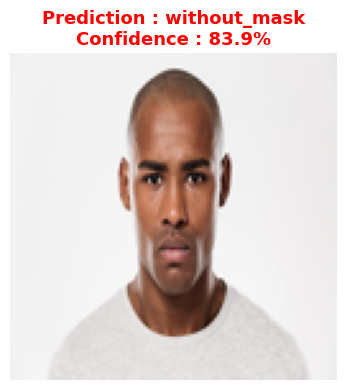

Prediction : without_mask
Confidence : 83.9%


In [34]:
predict_new_image(
    model       = model2,
    image_source= "https://img.magnific.com/free-photo/serious-young-african-man-standing-isolated_171337-9633.jpg?semt=ais_hybrid&w=740&q=80",
    class_names = class_names
)

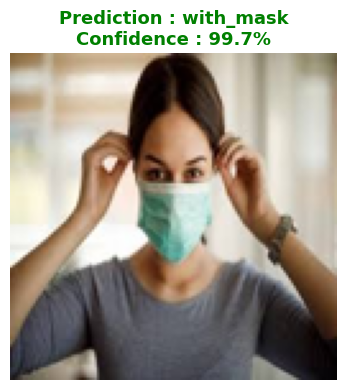

Prediction : with_mask
Confidence : 99.7%


In [33]:
predict_new_image(
    model       = model2,
    image_source= "https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcQbO_F0VgtPqkNtAbzkPgXkTdQiBIhTfze8Pw&s",
    class_names = class_names
)

In [ ]:
model2.save("face_mask_model.h5")